## Bulk RNA-seq Analysis with pydeseq2
#### Matej Lexa @2026 Summer School
### Day 2 (Tuesday, July 22)
To analyze the count data from the previous day (rememember featureCount output based on hisat2 alignment?), we will use a Python incarnation of DeSeq2 (originally an R package).

### Setting up the environment
Apart from pydeseq2 module, we will use pandas to work with dataframes and a couple of other supporting modules. Finally, matlpotlib is a dependency for plotting.

In [26]:
import os
import numpy as np
import pandas as pd
import pickle as pkl
import matplotlib.pyplot as plt
from pydeseq2.dds import DeseqDataSet
from pydeseq2.default_inference import DefaultInference
from pydeseq2.ds import DeseqStats

We will need a bit wider output space for tables. Adjust if you need a different number on your hardware. 

In [27]:
pd.options.display.width = 128
pd.options.display.max_columns = 12

If some of the modules are not available, you need to tweak your environment by installing the missing modules with pip.

### Pre-processing count data
Let's start where we left off and read in the feature counts, inspect them in Python and pre-process for use with pydeseq2. Pandas read_csv() will do the trick:

In [28]:
fc_raw = pd.read_csv("../hisat2/read_counts_all_s1.txt", sep="\t", comment="#", index_col=0, engine="python")
# check we got the sizes and content right
print(f"Raw featureCounts shape: {fc_raw.shape}")
print(fc_raw.columns.tolist()[:8])

Raw featureCounts shape: (41079, 11)
['Chr', 'Start', 'End', 'Strand', 'Length', 'SRR11449101_sorted.bam', 'SRR11449102_sorted.bam', 'SRR11449103_sorted.bam']


Make sure the sizes of the dataframe seem right (have you read in the filtered one?). We will not need the annotation columns, so let's drop them:

In [29]:
counts_fc = fc_raw.drop(columns=["Chr", "Start", "End", "Strand", "Length"])
# check we got the sizes and content right
print(f"Raw featureCounts shape: {counts_fc.shape}")
print(counts_fc.columns.tolist()[:8])

Raw featureCounts shape: (41079, 6)
['SRR11449101_sorted.bam', 'SRR11449102_sorted.bam', 'SRR11449103_sorted.bam', 'SRR11449109_sorted.bam', 'SRR11449110_sorted.bam', 'SRR11449111_sorted.bam']


We can also make the count column names a bit easier to read by just keeping the informative run ids:

In [30]:
counts_fc.columns = (counts_fc.columns.str.replace(r"_sorted\.bam", "", regex=True))
# check we got the sizes and content right
print(f"Cleaned counts shape: {counts_fc.shape}")
print(counts_fc.head(3))

Cleaned counts shape: (41079, 6)
         SRR11449101  SRR11449102  SRR11449103  SRR11449109  SRR11449110  SRR11449111
Geneid                                                                               
Gm26206            0            0            0            0            0            0
Xkr4               0            0            0            0            0            0
Gm53491            0            0            0            0            0            2


Let's save this count matrix to a file:

In [31]:
counts_fc.to_csv("./featurecounts_matrix.csv")

You may have noticed we have some lines with zeroes there. It is not necessary to keep these. Let us set some tresholds on which lines (genes) to keep for further analysis. This will take some logic which we better include as a function to call later:

In [32]:
def filter_low_counts(counts: pd.DataFrame, min_count: int = 10, min_samples\
: int = 3) -> pd.DataFrame:
    """
    Keep genes with at least min_count in at least min_samples samples.
    The min_samples value should match the size of your smallest group.
    """
    keep = (counts >= min_count).sum(axis=1) >= min_samples
    filtered = counts.loc[keep]
    print(f"Genes before filter: {len(counts)}")
    print(f"Genes after filter:  {len(filtered)}")
    return filtered


In [33]:
counts_fc_filtered = filter_low_counts(counts_fc)

Genes before filter: 41079
Genes after filter:  15168


Let's save this one as well:

In [9]:
counts_fc_filtered.to_csv("./featurecounts_matrix_filtered.csv")

### Finalizing metadata and count input files
There is one more input pydeseq2 needs - it's a description of the samples that needs to specify at least one factor differing across samples. In our case it is age. Create the file in an editor and check it's format:

In [10]:
metadata = pd.read_csv("./metadata.tsv", sep="\t", index_col=0)
print(metadata)

            age
SRR11449101   Y
SRR11449102   Y
SRR11449103   Y
SRR11449109   O
SRR11449110   O
SRR11449111   O


pydeseq2 will also require the count matrix in a transposed format:

In [34]:
counts_df = counts_fc_filtered.T
print(counts_df)

Geneid       Mrpl15  Lypla1  Tcea1  Atp6v1h  4732440D04Rik  Rb1cc1  ...    ND4   ND5  ND6    CYTB  TrnT  TrnP
SRR11449101    5359     296   1096      547             16    1100  ...  33461  5683  143  112213    18    29
SRR11449102    5359     292   1157      487             18    1027  ...  33524  5734  122  110355    29    23
SRR11449103    5431     284   1150      484             26    1026  ...  33487  5744  118  111039    33    21
SRR11449109    4386     307    745      452             59    1125  ...  30906  4914  212  110353    25    16
SRR11449110    4331     260    736      437             50    1043  ...  30307  4857  189  108795    24    17
SRR11449111    8961     542   1629      825            114    2239  ...  60338  9648  438  217715    47    34

[6 rows x 15168 columns]


### Running pydeseq2 differential expression analysis
Finally, we get to run the analysis using the deseq2() function after some initialization steps:

In [35]:
# Prepare environment and data ...
inference = DefaultInference(n_cpus=4)
dds = DeseqDataSet(counts=counts_df, metadata=metadata, design="~age", refit_cooks=True, inference=inference)
# ... and run
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.55 seconds.

Fitting dispersion trend curve...
... done in 0.22 seconds.

Fitting MAP dispersions...
... done in 1.73 seconds.

Fitting LFCs...
... done in 1.08 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.



In [36]:
ds = DeseqStats(dds, contrast=["age", "O", "Y"], inference=inference)
ds.summary()

Running Wald tests...


Log2 fold change & Wald test p-value: age O vs Y
                    baseMean  log2FoldChange     lfcSE       stat        pvalue          padj
Geneid                                                                                       
Mrpl15           5471.022211       -0.297564  0.029732 -10.008271  1.401808e-23  1.061399e-22
Lypla1            318.666068       -0.069920  0.097551  -0.716755  4.735256e-01  5.426954e-01
Tcea1            1062.691026       -0.567805  0.058451  -9.714175  2.623642e-22  1.908401e-21
Atp6v1h           525.523967       -0.236612  0.078532  -3.012956  2.587164e-03  4.991764e-03
4732440D04Rik      42.060307        1.463030  0.284049   5.150617  2.596304e-07  8.321122e-07
...                      ...             ...       ...        ...           ...           ...
ND5              5920.040309       -0.242431  0.028798  -8.418324  3.819073e-17  2.290236e-16
ND6               186.754814        0.694130  0.129723   5.350867  8.753397e-08  2.937686e-07
CYTB       

... done in 0.47 seconds.



The data can be accessed later without running the summary calculations again:

In [37]:
ds.results_df

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj
Geneid,,,,,,
Mrpl15,5471.022211,-0.297564,0.029732,-10.008271,1.401808e-23,1.061399e-22
Lypla1,318.666068,-0.069920,0.097551,-0.716755,4.735256e-01,5.426954e-01
Tcea1,1062.691026,-0.567805,0.058451,-9.714175,2.623642e-22,1.908401e-21
Atp6v1h,525.523967,-0.236612,0.078532,-3.012956,2.587164e-03,4.991764e-03
4732440D04Rik,42.060307,1.463030,0.284049,5.150617,2.596304e-07,8.321122e-07
...,...,...,...,...,...,...
ND5,5920.040309,-0.242431,0.028798,-8.418324,3.819073e-17,2.290236e-16
ND6,186.754814,0.694130,0.129723,5.350867,8.753397e-08,2.937686e-07
CYTB,123310.975246,-0.032280,0.018369,-1.757320,7.886325e-02,1.131435e-01


These results could be a good point to save the data for backup. We use pickle for the first, CSV/TSV for the latter:

In [38]:
with open("result_adata.pkl", "wb") as f:
    pkl.dump(dds.to_picklable_anndata(), f)

ds.results_df.to_csv("result_stats.csv")
ds.results_df.to_csv("result_stats.tsv", sep="\t")

ds.lfc_shrink(coeff="age[T.Y]")
ds.results_df.to_csv("result_stats_shrunk.tsv", sep="\t")

Fitting MAP LFCs...


Shrunk log2 fold change & Wald test p-value: age[T.Y]
                    baseMean  log2FoldChange     lfcSE       stat        pvalue          padj
Geneid                                                                                       
Mrpl15           5471.022211        0.296931  0.029713 -10.008271  1.401808e-23  1.061399e-22
Lypla1            318.666068        0.068220  0.096946  -0.716755  4.735256e-01  5.426954e-01
Tcea1            1062.691026        0.564140  0.058361  -9.714175  2.623642e-22  1.908401e-21
Atp6v1h           525.523967        0.232973  0.078320  -3.012956  2.587164e-03  4.991764e-03
4732440D04Rik      42.060307       -1.378366  0.285142   5.150617  2.596304e-07  8.321122e-07
...                      ...             ...       ...        ...           ...           ...
ND5              5920.040309        0.241929  0.028789  -8.418324  3.819073e-17  2.290236e-16
ND6               186.754814       -0.674788  0.129316   5.350867  8.753397e-08  2.937686e-07
CYTB  

... done in 1.94 seconds.



### Visualizing the data
Visualizing results is a critical step for exploring differential gene expression data. The most common diagnostic and exploratory plots include MA-plots (to check for biases and outlier genes), Volcano plots (to identify significantly up/down-regulated genes), Heatmaps (to show expression patterns across samples), and count plots.

Let us make a volcano plot with matplotlib:

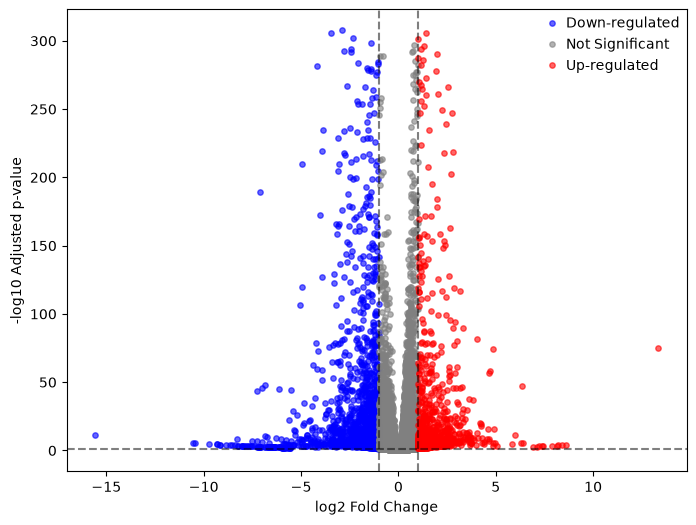

In [39]:
res_df = ds.results_df

# Define significance thresholds
padj_thresh = 0.05
lfc_thresh = 1.0

# Calculate -log10(padj)
res_df['-log10(padj)'] = -np.log10(res_df['padj'])

# Categorize genes for coloring
res_df['Significance'] = 'Not Significant'
res_df.loc[(res_df['padj'] < padj_thresh) & (res_df['log2FoldChange'] > lfc_thresh), 'Significance'] = 'Up-regulated'
res_df.loc[(res_df['padj'] < padj_thresh) & (res_df['log2FoldChange'] < -lfc_thresh), 'Significance'] = 'Down-regulated'

# Plotting
fig, ax = plt.subplots(figsize=(8, 6))

colors = {'Not Significant': 'gray', 'Up-regulated': 'red', 'Down-regulated': 'blue'}
for sig, group in res_df.groupby('Significance'):
    ax.scatter(group['log2FoldChange'], group['-log10(padj)'], 
               color=colors[sig], alpha=0.6, label=sig, s=15)

ax.set_xlabel('log2 Fold Change')
ax.set_ylabel('-log10 Adjusted p-value')
ax.axhline(-np.log10(padj_thresh), color='black', linestyle='--', alpha=0.5)
ax.axvline(lfc_thresh, color='black', linestyle='--', alpha=0.5)
ax.axvline(-lfc_thresh, color='black', linestyle='--', alpha=0.5)
ax.legend()
plt.show()

pydeseq2 has a builtin function for examining the differential analysis data:

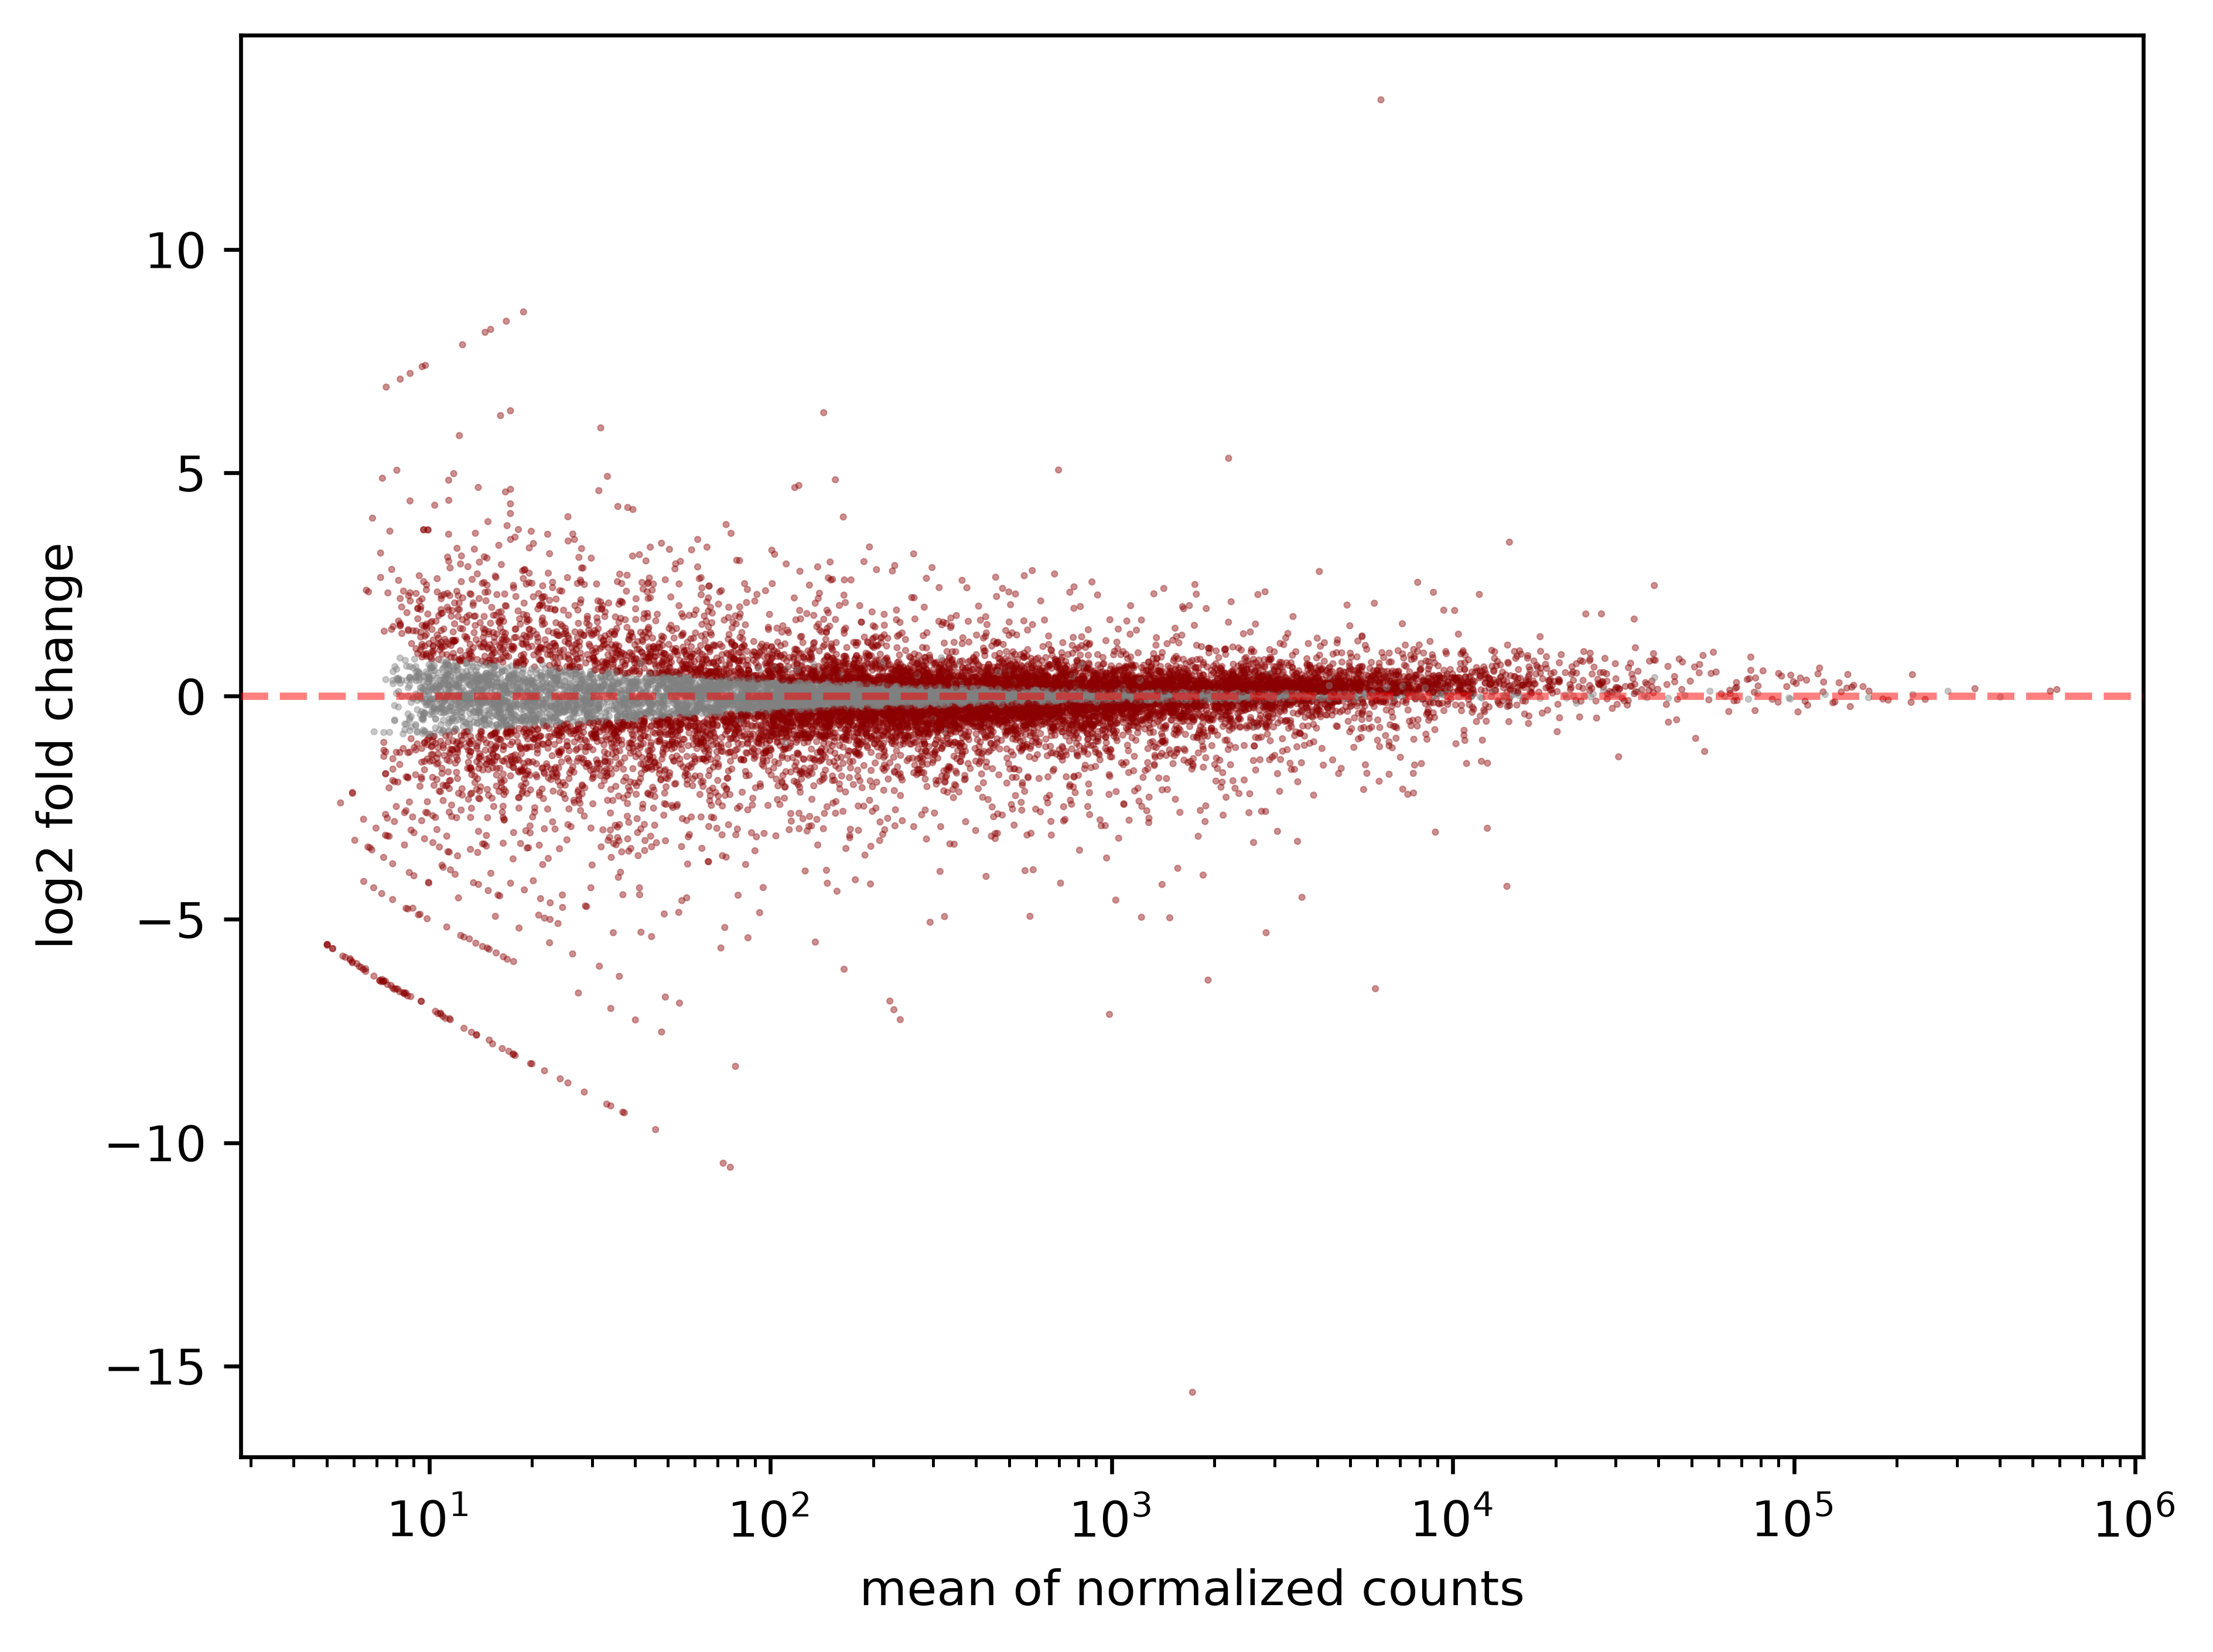

In [17]:
ds.plot_MA()

## More plots with pertpy
Getting ready:

In [18]:
import warnings
import decoupler as dc
import pertpy as pt
import scanpy as sc
warnings.filterwarnings("ignore")

In [22]:
pds2 = pt.tl.PyDESeq2(adata=dds, design="~age")
pds2.fit()
res_df = pds2.test_contrasts(pds2.contrast(column="age", baseline="Y", group_to_compare="O"))
res_df.head(10)

Fitting size factors...
... done in 0.00 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 0.74 seconds.

Fitting dispersion trend curve...
... done in 0.22 seconds.

Fitting MAP dispersions...
... done in 0.81 seconds.

Fitting LFCs...
... done in 0.75 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                    baseMean  log2FoldChange     lfcSE       stat        pvalue          padj
Geneid                                                                                       
Mrpl15           5471.022211       -0.297564  0.029732 -10.008271  1.401808e-23  1.061399e-22
Lypla1            318.666068       -0.069920  0.097551  -0.716755  4.735256e-01  5.426954e-01
Tcea1            1062.691026       -0.567805  0.058451  -9.714175  2.623642e-22  1.908401e-21
Atp6v1h           525.523967       -0.236612  0.078532  -3.012956  2.587164e-03  4.991764e-03
4732440D04Rik      42.060307        1.463030  0.284049   5.150617  2.596304e-07  8.321122e-07
...                      ...             ...       ...        ...           ...           ...
ND5              5920.040309       -0.242431  0.028798  -8.418324  3.819073e-17  2.290236e-16
ND6               186.754814        0.694130  0.129723   5.350867  8.753397e-08  2.937686

... done in 0.43 seconds.



,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,Sbspon,1916.172793,6.365083,0.135249,47.061852,0.0,0.0,None
1,mt-Rnr2,27250.680065,-1.842013,0.023992,-76.777620,0.0,0.0,None
2,mt-Rnr1,5263.726776,-1.234067,0.030134,-40.952599,0.0,0.0,None
3,Imp3,5473.775220,2.092396,0.033539,62.387235,0.0,0.0,None
4,Rpl41,34255.689170,-1.083843,0.025039,-43.286682,0.0,0.0,None
5,Mt1,7720.631065,1.543871,0.028203,54.741463,0.0,0.0,None
6,Ahsp,1769.285030,-2.284414,0.049447,-46.199712,0.0,0.0,None
7,Atp5f1e,18067.132977,-1.003615,0.025967,-38.649593,0.0,0.0,None
8,Apoe,54670.571872,1.240228,0.020025,61.935450,0.0,0.0,None
9,Selp,1561.062677,3.858498,0.074738,51.626834,0.0,0.0,None


And the volcano plot again:

NaNs encountered, dropping rows with NaNs
0s encountered for p value, replacing with 1e-323


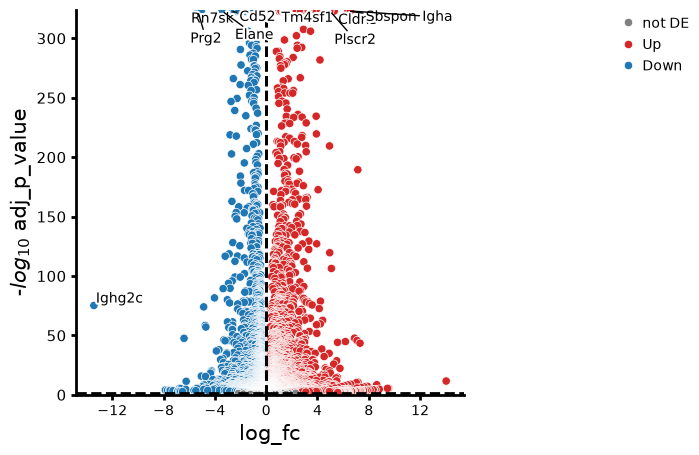

In [23]:
pds2.plot_volcano(res_df, log2fc_threshold=0)

A fold change plot:

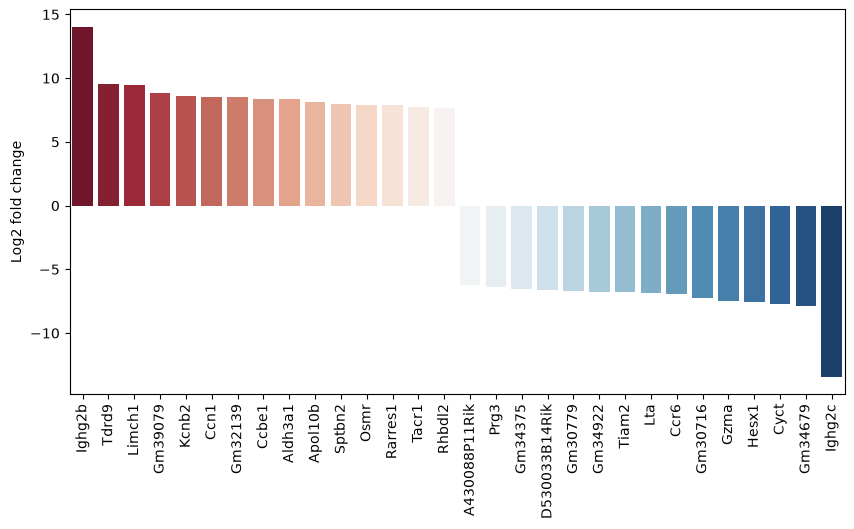

In [24]:
pds2.plot_fold_change(res_df, n_top_vars=15)

... and dispersion estimates:

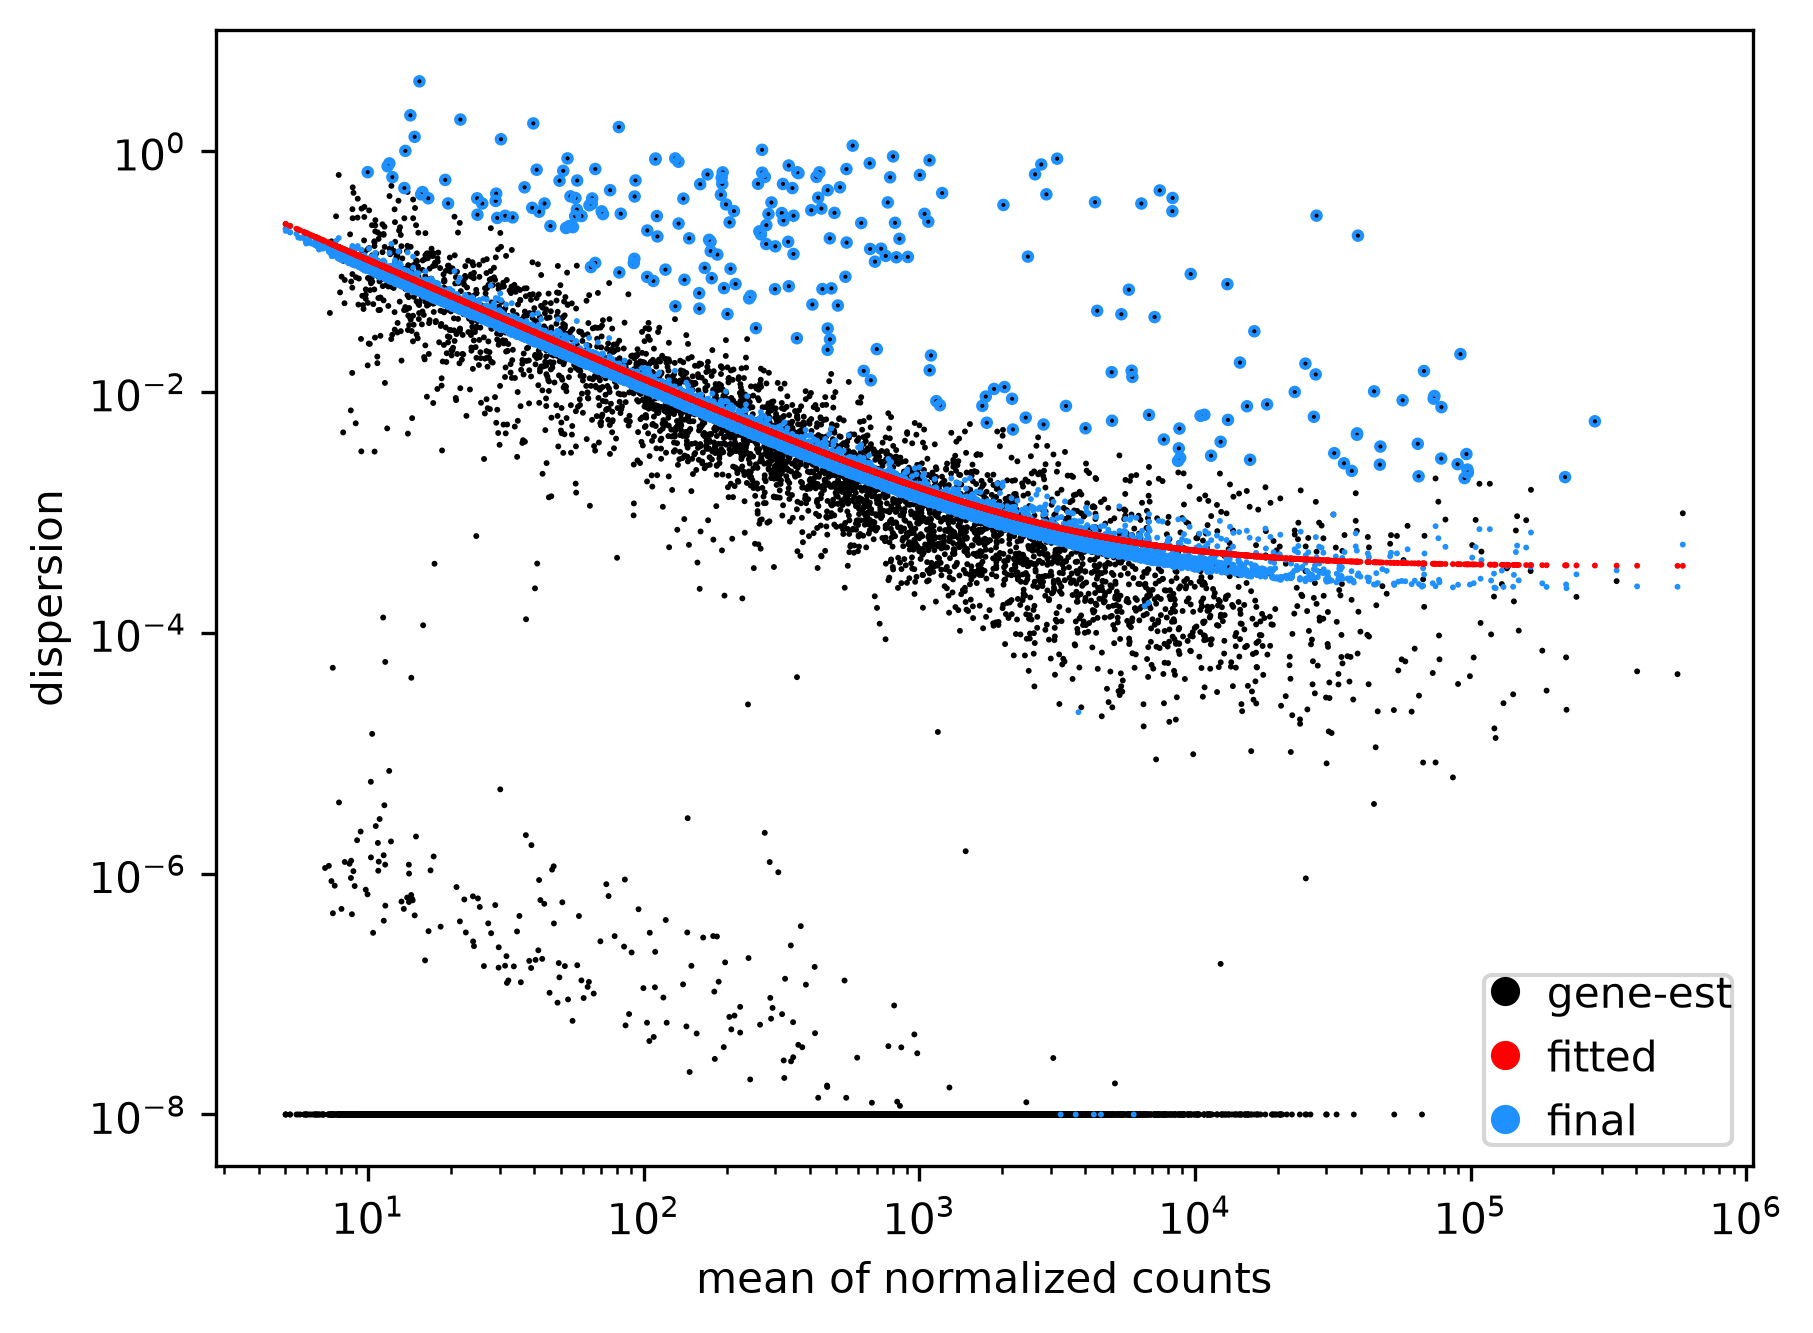

In [25]:
pds2.plot_disp_ests(point_size=0.1)

Finally a heatmap of selected genes using the seaborn module:

In [46]:
import seaborn as sns
from scipy.stats import zscore

In [47]:
# get normalized counts and apply log1p transformation
norm_counts = dds.layers["normed_counts"]
log_norm_counts = pd.DataFrame(
    np.log1p(norm_counts), 
    index=dds.obs_names, 
    columns=dds.var_names
)

In [48]:
sig_genes = ["Gfi1b", "Junb", "Sox4", "Stat1"]

In [49]:
heatmap_data = log_norm_counts[sig_genes]

In [50]:
heatmap_z = heatmap_data.apply(zscore, axis=0)

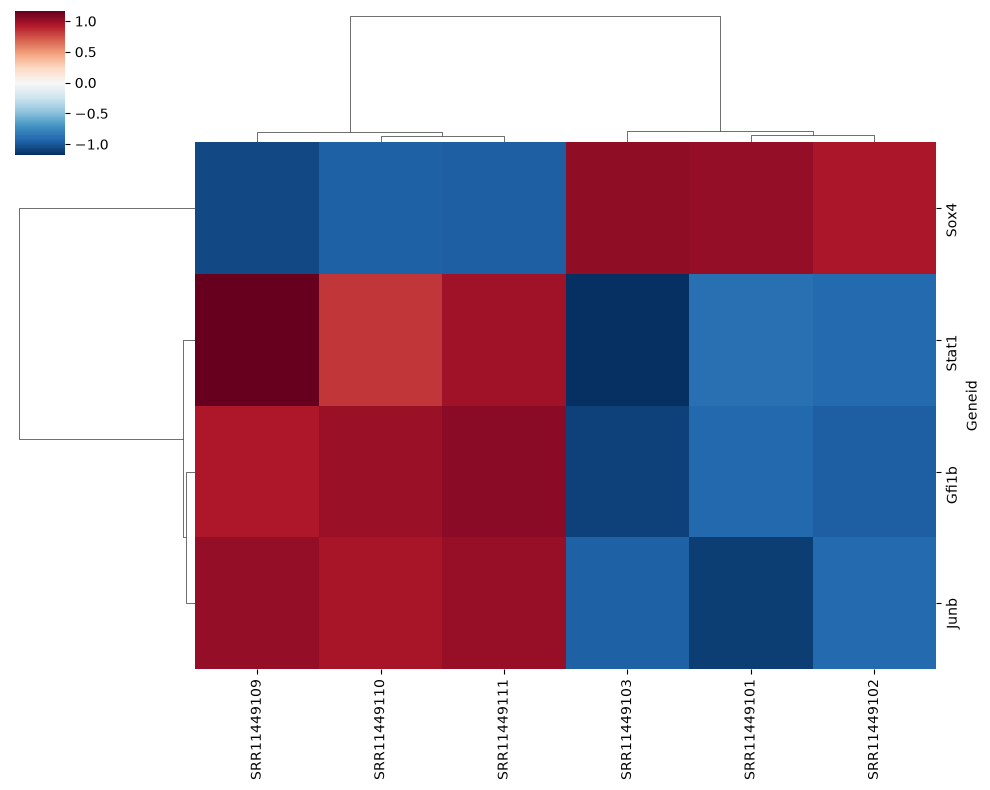

In [51]:
sns.clustermap(heatmap_z.T, cmap="RdBu_r", z_score=None, 
               figsize=(10, 8), col_cluster=True, row_cluster=True)
plt.show()